## Подготовка данных

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage

In [2]:
!gdown 15uFEMCKuBQWRuTO32wSmxWQukBGtnADA
!unzip -q /content/kodak.zip

Downloading...
From: https://drive.google.com/uc?id=15uFEMCKuBQWRuTO32wSmxWQukBGtnADA
To: /content/kodak.zip
100% 6.38M/6.38M [00:00<00:00, 46.3MB/s]


## Свёртка 2D для одноканального изображения

Будем считать, что изображение уже переведено в grayscale и задаётся матрицей яркостей:

$$
I \in \mathbb{R}^{H \times W},
$$

где $I[y,x]$ — значение яркости пикселя в координате $(y,x)$.

Свёртка применяет к изображению небольшую матрицу весов — ядро (англ. kernel):  

$$
K \in \mathbb{R}^{k \times k}.
$$


#### Как работает «скользящее окно»

Чтобы получить один пиксель результата, мы:

- берём фрагмент изображения размером $k \times k$ вокруг текущей позиции;
- поэлементно умножаем его на ядро;
- складываем все полученные значения.

Получив одно число, сдвигаем окно и повторяем процесс — так строится выходная карта.



#### Формула дискретной 2D-свёртки

Обычно выбирают нечётное $k$, например, $3$ или $5$. Обозначим:

$$
r = \frac{k-1}{2}.
$$

Тогда значение результата $O$ в точке $(y,x)$ вычисляется так:

$$
O[y,x] =
\sum_{i=-r}^{r}
\sum_{j=-r}^{r}
I[y+i, x+j] \cdot K[i+r, j+r].
$$

Смысл формулы простой: мы берём соседние пиксели вокруг $(y,x)$, умножаем на соответствующие веса ядра и суммируем.



#### Как интерпретировать результат

Свёртка показывает, насколько локальный фрагмент изображения похож на шаблон, заданный ядром:

- большое положительное значение → структура совпадает с ядром;
- значение около нуля → совпадения почти нет;
- отрицательное значение → структура противоположна ядру.



#### Мини-пример: считаем вручную

Пусть

$$
I=
\begin{pmatrix}
1&2&3\\
4&5&6\\
7&8&9
\end{pmatrix},
\quad
K=
\begin{pmatrix}
1&0\\
0&-1
\end{pmatrix}.
$$

Первый элемент результата получаем из левого верхнего блока $2\times 2$:

$$
\begin{pmatrix}
1&2\\
4&5
\end{pmatrix}.
$$

Считаем сумму произведений:

$$
(1\cdot 1) + (2\cdot 0) + (4\cdot 0) + (5\cdot (-1)) = -4.
$$

Это и есть первый пиксель выходной карты.



#### Зачем нужна свёртка

Свёртка позволяет учитывать локальную структуру изображения и извлекать признаки (границы, текстуры, контуры).

Именно эта операция лежит в основе свёрточных нейронных сетей (CNN).


### Задание 1. Реализация Conv2D (один канал)

Твоя задача — реализовать простейшую 2D-свёртку для одноканального изображения, для простоты — без использования padding и stride.

#### Твой код

In [ ]:
import numpy as np

def conv2d_valid(image, kernel)

    H, W = image.shape
    kH, kW = kernel.shape

    # Напиши код здесь
    pass


#### Решение для семинариста

In [3]:
import numpy as np

def conv2d_valid(image, kernel):

    H, W = image.shape
    kH, kW = kernel.shape

    out_h = H - kH + 1
    out_w = W - kW + 1

    out = np.zeros((out_h, out_w), dtype=float)

    for y in range(out_h):
        for x in range(out_w):
            patch = image[y:y+kH, x:x+kW]
            out[y, x] = np.sum(patch * kernel)

    return out

#### Проверим реализацию на примере

Возьмём изображение $3 \times 3$ и ядро $2 \times 2$ и посчитаем результат.


In [4]:
image_small = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
], dtype=float)

kernel_small = np.array([
    [1, 0],
    [0, -1]
], dtype=float)

out_small = conv2d_valid(image_small, kernel_small)
print("image:\n", image_small)
print("kernel:\n", kernel_small)
print("output:\n", out_small)


image:
 [[1. 2. 3.]
 [4. 5. 6.]
 [7. 8. 9.]]
kernel:
 [[ 1.  0.]
 [ 0. -1.]]
output:
 [[-4. -4.]
 [-4. -4.]]


## Выделение границ
Как ты помнишь из лекции, задавая веса в ядре свёртки, можно получать различные фильтры для изображений. Прежде чем мы начнём их разбирать, рассмотрим на примере нашей свёртки фильтр, который хорошо выделяет границы:

$$
K=
\begin{pmatrix}
-1 & -1 & -1 \\
-1 &  8 & -1 \\
-1 & -1 & -1
\end{pmatrix}.
$$

Идея в том, что внутри однородных областей пиксели, скорее всего, коррелированны, поэтому после свёртки с нашим ядром значения в таких областях будут близки к нулю, а на границах — наоборот.


In [5]:
img = cv2.imread("kodak/kodim03.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(float)


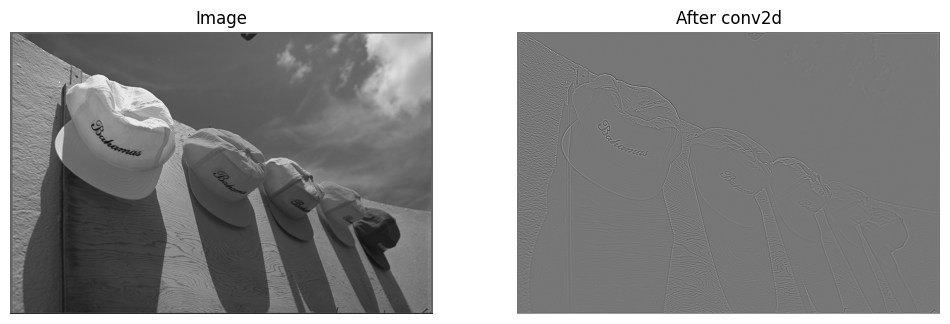

In [6]:
edge_kernel = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
], dtype=float)

edges = conv2d_valid(gray, edge_kernel)

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap="gray")
plt.title("Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edges, cmap="gray")
plt.title("After conv2d")
plt.axis("off")

plt.show()


## Фильтры

In [7]:
# Вспомогательные функции для нормализации и визуализации
def normalize(x):
    x = x.astype(np.float32)
    mn, mx = float(np.min(x)), float(np.max(x))
    if mx - mn < 1e-8:
        return np.zeros_like(x)
    return (x - mn) / (mx - mn)

def show(a, b, title_a="Input", title_b="Output", figsize=(12, 5)):
    plt.figure(figsize=figsize)
    plt.subplot(1, 2, 1)
    plt.imshow(a, cmap="gray")
    plt.title(title_a)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(b, cmap="gray")
    plt.title(title_b)
    plt.axis("off")
    plt.show()

In [8]:
# Загрузим изображение
img = cv2.imread("kodak/kodim04.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(float)

## Фильтр Гаусса

Фильтр Гаусса (англ. Gaussian Blur) нужен, чтобы сгладить изображение и подавить шум, «усреднив» пиксели в окрестности.

Значение нового пикселя — это взвешенное среднее соседних пикселей, где ближние получают больший вес, а дальние — меньший.

Непрерывная 2D-формула Гаусса:

$$
G(x, y) = \frac{1}{2\pi\sigma^2}\exp\left(-\frac{x^2 + y^2}{2\sigma^2}\right),
$$

где $\sigma$ управляет «силой» размытия: чем больше $\sigma$, тем сильнее сглаживание.

На практике используется дискретное ядро $k\times k$, заполненное значениями $G(x,y)$.

Результат фильтрации можно представить как свёртку:

$$
I_{blur} = I * G,
$$

где $I$ — исходное изображение (grayscale);

$G$ — гауссово ядро.


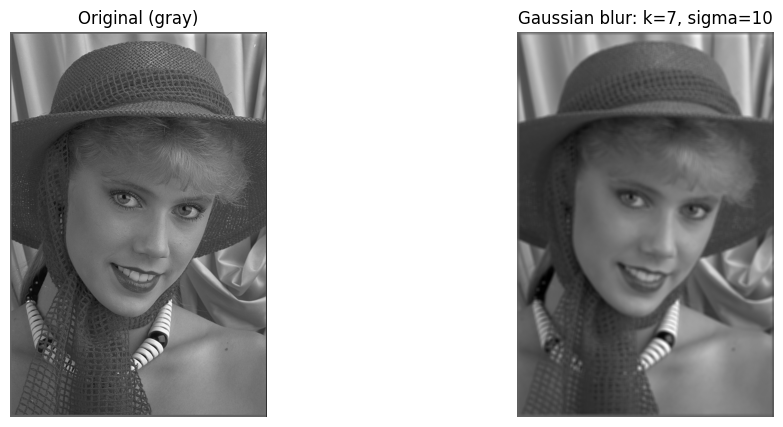

In [ ]:
blur = cv2.GaussianBlur(gray, (7, 7), sigmaX=10)

show(normalize(gray), normalize(blur),
      title_a="Original (gray)",
      title_b="Gaussian blur: k=7, sigma=10")

### Вопросы для студентов

1) Если увеличить `sigma`, но оставить размер ядра `ksize` маленьким, будет ли размытие корректным? Почему размер ядра должен быть согласован с `sigma`?

2) Что сильнее влияет на степень размытия — `sigma` или `ksize`? Можно ли получить сильное размытие при большом значении `ksize`, но маленьком `sigma`?

3) Что произойдёт с изображением, если сделать значение `sigma` очень большим? К какому виду будет стремиться изображение?


#### Ответы для семинариста

1) Если `sigma` большая, а `ksize` маленький, размытие получается не вполне корректным: гауссово ядро как бы “обрезается” по краям. В этом случае уже не учитывается заметная часть весов, и фильтр хуже приближает настоящий Gaussian Blur. Интуитивно: большая `sigma` означает широкое размытие, значит и окно должно быть достаточно большим, чтобы это размытие реально поместилось в ядро.

2) На степень размытия сильнее влияет именно `sigma`, потому что она задаёт, как быстро убывают веса от центра. `ksize` не делает размытие сильным: он только даёт фильтру область, в которой можно учитывать соседей. Поэтому при большом `ksize`, но маленькой `sigma` сильного размытия не будет — почти весь вес останется около центра.

3) Если сделать `sigma` очень большой, изображение будет всё сильнее сглаживаться: исчезнут мелкие детали, текстуры, резкие границы. В пределе картинка будет стремиться к очень плавной, почти однородной по яркости версии исходного изображения. То есть локальная структура начнет постепенно “смываться”.

Теперь посмотрим, как меняется изображение при изменении параметра фильтров.

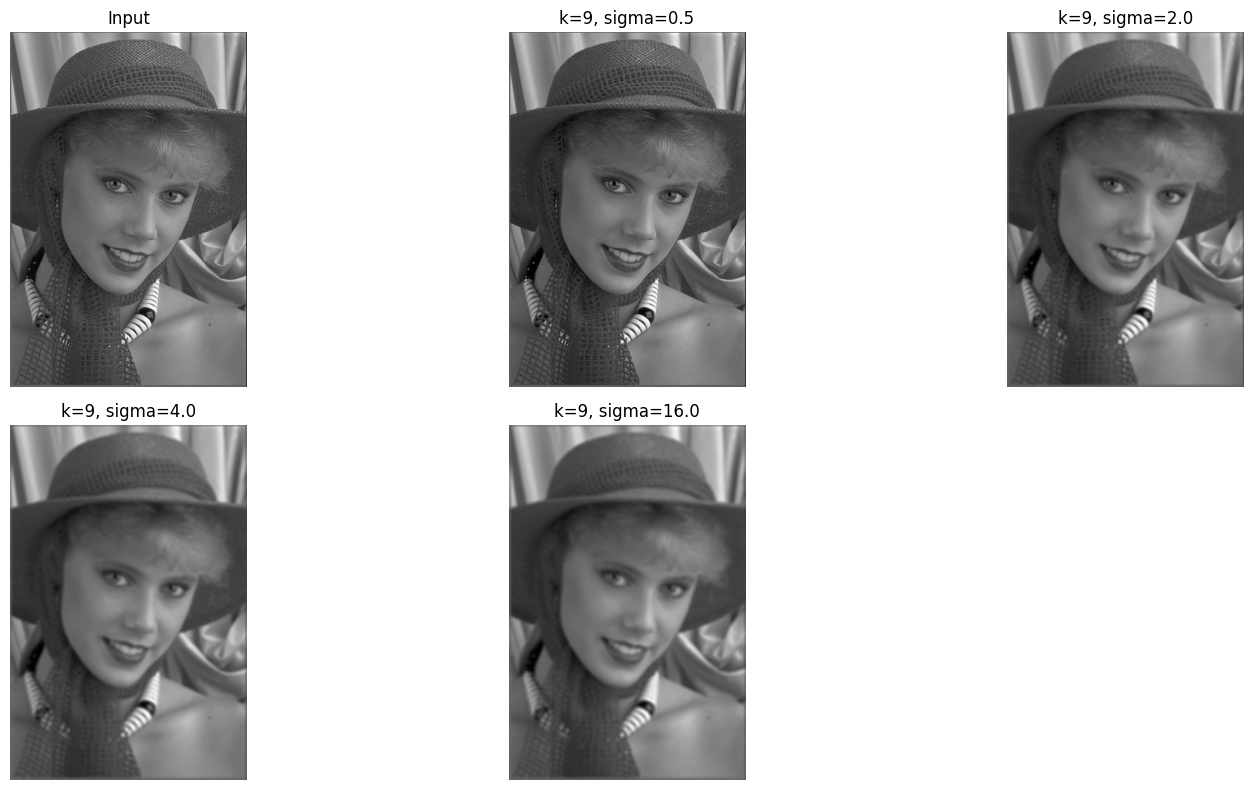

In [ ]:
ksize =  nine = 9  # Фиксируем ядро
sigmas = [0.5, 2.0, 4.0, 16.0]

plt.figure(figsize=(16, 8))

# Исходник
plt.subplot(2, 3, 1)
plt.imshow(normalize(gray), cmap="gray")
plt.title("Input")
plt.axis("off")

for i, s in enumerate(sigmas, start=2):
    out = cv2.GaussianBlur(gray, (ksize, ksize), sigmaX=s)
    plt.subplot(2, 3, i)
    plt.imshow(normalize(out), cmap="gray")
    plt.title(f"k={ksize}, sigma={s}")
    plt.axis("off")

plt.tight_layout()
plt.show()



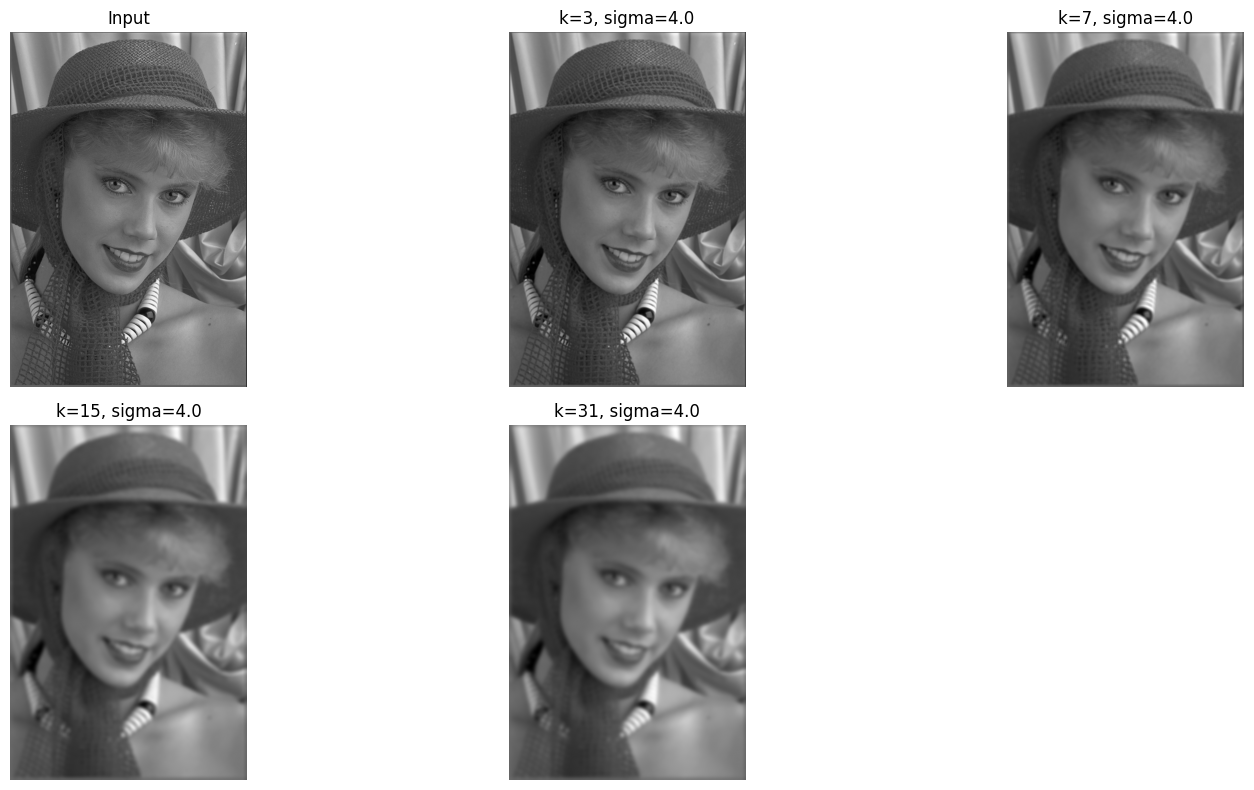

In [ ]:
sigma = 4.0
ksizes = [3, 7, 15, 31]

plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
plt.imshow(normalize(gray), cmap="gray")
plt.title("Input")
plt.axis("off")

for i, k in enumerate(ksizes, start=2):
    out = cv2.GaussianBlur(gray, (k, k), sigmaX=sigma)
    plt.subplot(2, 3, i)
    plt.imshow(normalize(out), cmap="gray")
    plt.title(f"k={k}, sigma={sigma}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## Градиент изображения

Если Gaussian Blur сглаживает изображение, то градиент работает иначе — измеряет, насколько резко меняется яркость.

Идея простая: градиент — это производная функции яркости. В непрерывном случае:

$$
\nabla I =
\left(
\frac{\partial I}{\partial x},
\frac{\partial I}{\partial y}
\right).
$$

В дискретном случае производные приближаются разностями.

#### Простейшие ядра

- Производная по $X$:

$$
K_x =
\begin{pmatrix}
-1 & 0 & 1
\end{pmatrix}.
$$

- Производная по $Y$:

$$
K_y =
\begin{pmatrix}
-1 \\
0 \\
1
\end{pmatrix}.
$$

Мы считаем:

$$
G_x = I * K_x;
$$

$$
G_y = I * K_y.
$$

А затем вычисляем величину градиента:

$$
|\nabla I| = \sqrt{G_x^2 + G_y^2}.
$$

Если значение большое, в этой точке есть резкий перепад яркости (граница).


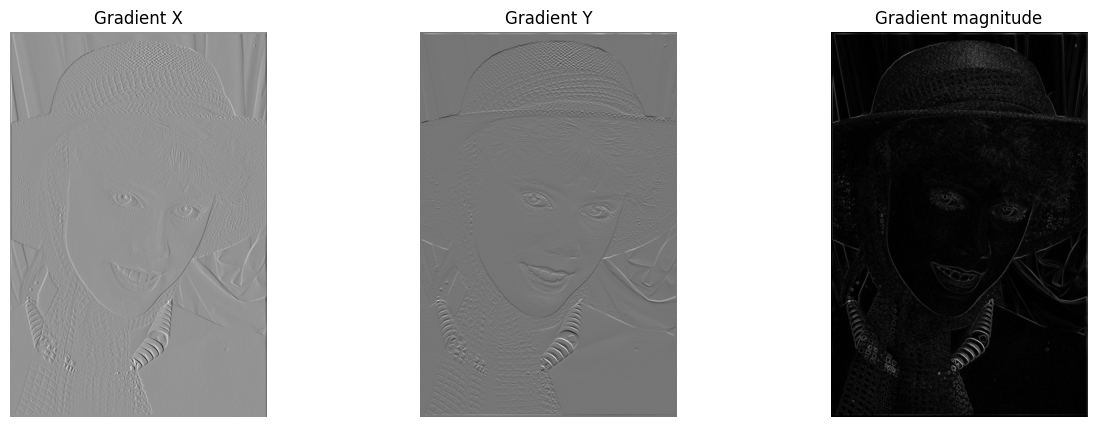

In [ ]:
gray = np.ascontiguousarray(gray.astype(np.float32))

def gradient(gray):
    kx = np.array([[-1, 0, 1]], dtype=np.float32)
    ky = np.array([[-1], [0], [1]], dtype=np.float32)

    gx = cv2.filter2D(gray, ddepth=-1, kernel=kx)
    gy = cv2.filter2D(gray, ddepth=-1, kernel=ky)

    mag = np.sqrt(gx**2 + gy**2)
    return gx, gy, mag

gx, gy, mag = gradient(gray)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(normalize(gx), cmap="gray")
plt.title("Gradient X")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(normalize(gy), cmap="gray")
plt.title("Gradient Y")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(normalize(mag), cmap="gray")
plt.title("Gradient magnitude")
plt.axis("off")

plt.show()


### Вопросы для студентов

1) Почему градиент в однородных областях изображения почти нулевой?

2) Почему шум усиливается при вычислении градиента?

3) Если на изображении есть вертикальная граница,
   какой компонент будет больше: $G_x$ или $G_y$? Почему?


#### Ответы для семинариста

1) В однородных областях яркость почти не меняется от пикселя к пикселю, а градиент как раз измеряет изменение яркости. Поэтому там значения $G_x$, $G_y$  и величина градиента близки к нулю. На практике они могут быть не совсем нулевыми из-за шума, текстуры и дискретности изображения.

2) Шум усиливается, потому что градиент — это по сути производная, которая очень чувствительна к быстрым мелким изменениям. Даже если соседние пиксели случайно немного отличаются, оператор воспринимает это как перепад яркости. Поэтому шум, который сам по себе выглядит как высокочастотная рябь, после градиента становится заметнее.

3) Для вертикальной границы сильнее будет компонент $G_x$. Причина в том, что у такой границы яркость резко меняется при движении по горизонтали, то есть вдоль оси $x$, а вдоль $y$ обычно почти не меняется. Иначе говоря: сама граница вертикальная, а направление максимального изменения — горизонтальное.

Теперь проведём интересный эксперимент: посмотрим, как фильтр Гаусса влияет на градиент.

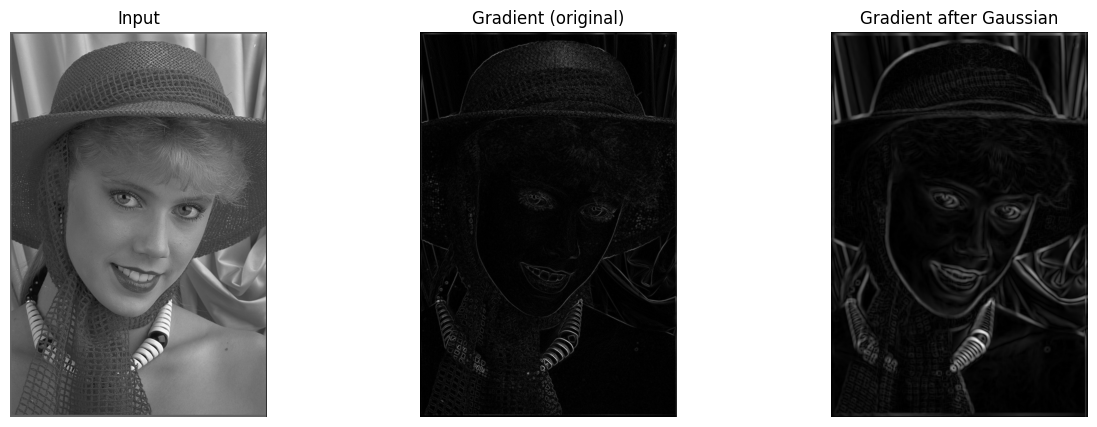

In [ ]:
# Градиент исходного
_, _, mag_original = gradient(gray)

# Размываем
blurred = cv2.GaussianBlur(gray, (9, 9), sigmaX=4.0)

# Градиент размытого
_, _, mag_blurred = gradient(blurred)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(normalize(gray), cmap="gray")
plt.title("Input")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(normalize(mag_original), cmap="gray")
plt.title("Gradient (original)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(normalize(mag_blurred), cmap="gray")
plt.title("Gradient after Gaussian")
plt.axis("off")

plt.show()



## Фильтр Собеля

Мы уже рассмотрели «классический» градиент:

$$
K_x = [-1, 0, 1];
$$

$$
K_y = [-1, 0, 1]^T.
$$

Но такой оператор очень чувствителен к шуму.

Фильтр Собеля — это улучшенная версия градиента.

Он сочетает:

- вычисление производной,
- локальное сглаживание.

#### Ядра Собеля

- По $X$:

$$
S_x =
\begin{pmatrix}
-1 & 0 & 1 \\
-2 & 0 & 2 \\
-1 & 0 & 1
\end{pmatrix}.
$$

- По $Y$:

$$
S_y =
\begin{pmatrix}
-1 & -2 & -1 \\
0 & 0 & 0 \\
1 & 2 & 1
\end{pmatrix}.
$$

> **Важно.** Центральная строка (или столбец) имеет больший вес (`2`). Это делает фильтр менее чувствительным к шуму.



Формально:

$$
G_x = I * S_x
$$

$$
G_y = I * S_y
$$

$$
|\nabla I| = \sqrt{G_x^2 + G_y^2}
$$

Собель выделяет границы устойчивее, чем простой градиент.


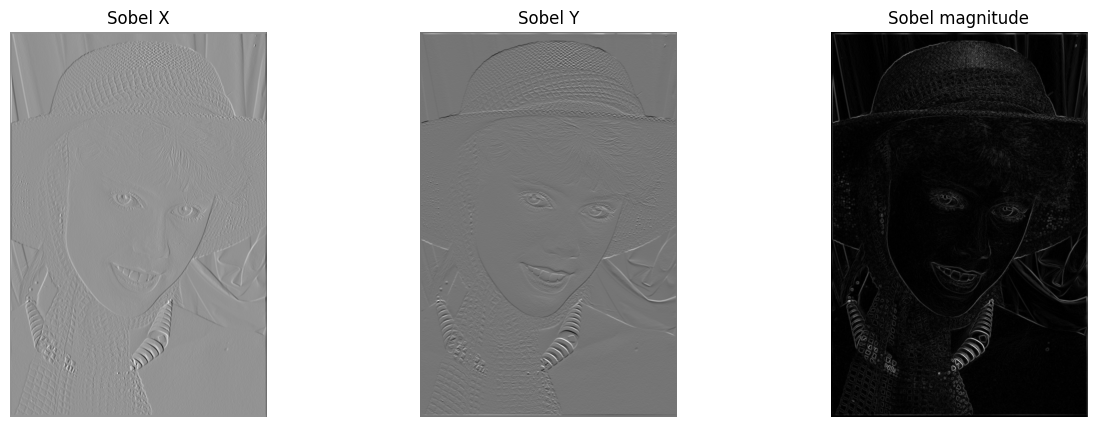

In [ ]:
gray = gray.astype(np.float32)

def sobel_filter(gray, ksize=3):
    gx = cv2.Sobel(gray, cv2.CV_32F, dx=1, dy=0, ksize=ksize)
    gy = cv2.Sobel(gray, cv2.CV_32F, dx=0, dy=1, ksize=ksize)
    magnitude = np.sqrt(gx**2 + gy**2)
    return gx, gy, magnitude

sx, sy, smag = sobel_filter(gray, ksize=3)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(normalize(sx), cmap="gray")
plt.title("Sobel X")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(normalize(sy), cmap="gray")
plt.title("Sobel Y")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(normalize(smag), cmap="gray")
plt.title("Sobel magnitude")
plt.axis("off")

plt.show()


### Вопросы для студентов

1) Почему Собель менее чувствителен к шуму, чем простой градиент?

2) Почему в центре ядра стоят числа `2`, а не `1`?

3) Если на изображении есть горизонтальная граница,
   какой компонент будет больше: $G_x$ или $G_y$?


#### Ответы для семинариста

1) Собель менее чувствителен к шуму, потому что он не просто берёт разность соседних пикселей, а одновременно делает небольшое локальное сглаживание. То есть он оценивает производную более устойчиво, используя информацию из окрестности, а не из одной пары пикселей. Поэтому случайные скачки яркости влияют на него слабее, чем на простой градиент.

2) Числа `2` в центре нужны, чтобы сильнее учитывать центральную строку или столбец и делать оценку производной устойчивее. Интуитивно: мы всё ещё ищем направление изменения яркости, но делаем это не “жёстко”, а с небольшим усреднением по соседям. Поэтому Собель лучше подавляет мелкий шум и даёт более аккуратные границы.

3) Для горизонтальной границы больше будет $G_y$. Здесь яркость резко меняется при движении сверху вниз или снизу вверх, то есть вдоль оси $y$. Компонент $G_x$ в таком случае обычно меньше, потому что вдоль самой границы яркость меняется слабее.

Сравним классический градиент и градиент Собеля.

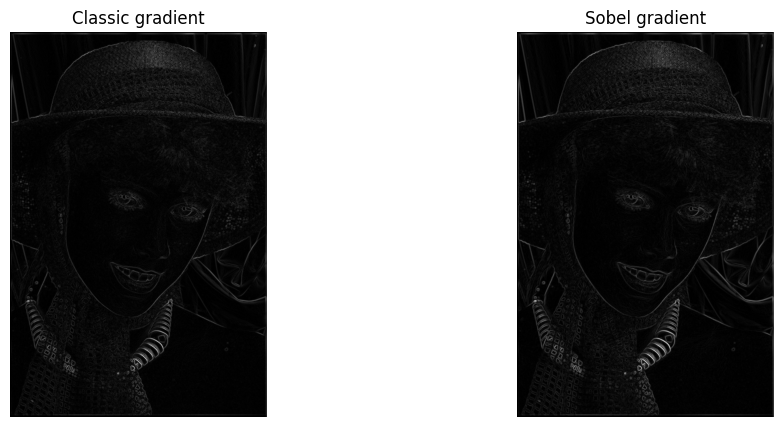

In [ ]:
_, _, mag_classic = gradient(gray)
_, _, mag_sobel = sobel_filter(gray, ksize=3)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(normalize(mag_classic), cmap="gray")
plt.title("Classic gradient")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(normalize(mag_sobel), cmap="gray")
plt.title("Sobel gradient")
plt.axis("off")

plt.show()


Посмотрим, как размер ядра влияет на градиент.

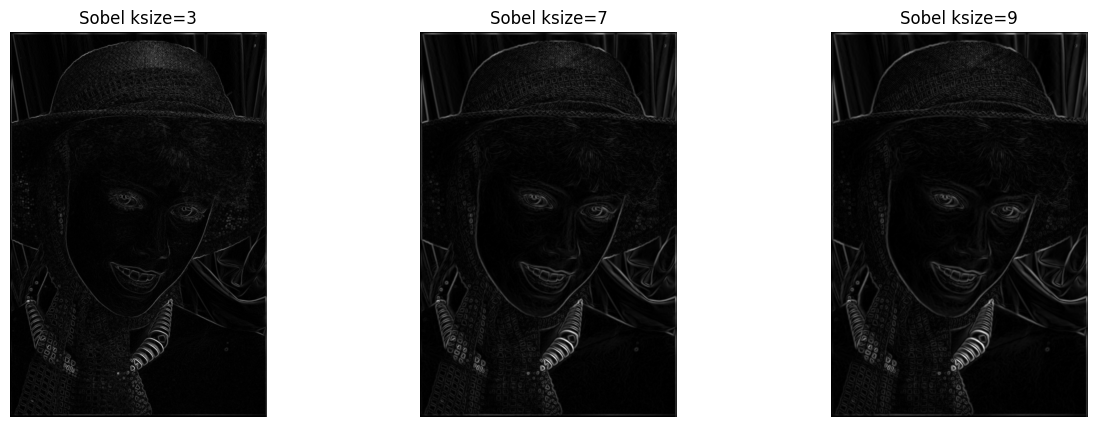

In [ ]:
ksizes = [3, 7, 9]

plt.figure(figsize=(15,5))

for i, k in enumerate(ksizes):
    _, _, mag = sobel_filter(gray, ksize=k)
    plt.subplot(1,3,i+1)
    plt.imshow(normalize(mag), cmap="gray")
    plt.title(f"Sobel ksize={k}")
    plt.axis("off")

plt.show()


## Фильтр высоких частот

До этого мы видели два примера обработки изображений:

- Gaussian Blur, который сглаживает изображение (оставляет низкие частоты);
- градиент, который усиливает резкие изменения.

Теперь рассмотрим фильтр высоких частот (англ. High-Pass), который явно оставляет только детали.

Фильтр высоких частот подавляет низкие частоты и оставляет высокие, поэтому на выходе остаются в основном детали изображения.


### Идея High-Pass

Вот самый простой способ получить высокие частоты.

1) Размыть изображение (получить низкие частоты).
2) Вычесть размытие из оригинала.

$$
I_{high} = I - G_\sigma * I,
$$


- где $G_\sigma$ — гауссов фильтр;
- $*$ — свёртка.

То есть оригинал = низкие частоты + высокие частоты. Мы оставляем только второе.


### Эффекты

High-pass-фильтр:

- убирает фон,
- усиливает детали,
- усиливает шум.


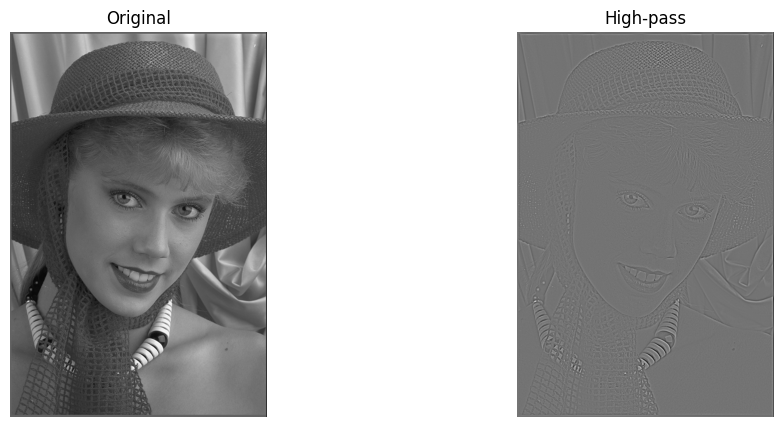

In [ ]:
gray = gray.astype(np.float32)

def high_pass_filter(gray, ksize=9, sigma=2.0):
    blurred = cv2.GaussianBlur(gray, (ksize, ksize), sigmaX=sigma)
    high = gray - blurred
    return high

hp = high_pass_filter(gray, ksize=9, sigma=2.0)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(normalize(gray), cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(normalize(hp), cmap="gray")
plt.title("High-pass")
plt.axis("off")

plt.show()


### Вопросы для студентов

1) Почему фон почти исчезает после high-pass-фильтрации?

2) Почему шум становится заметнее?

3) Что произойдёт, если сделать значение `sigma` очень большим?


#### Ответы для семинариста

1) Фон почти исчезает, потому что high-pass удаляет медленные, плавные изменения яркости. А именно к ним относятся фон, неравномерное освещение, большие гладкие области. После вычитания размытой версии остаётся в основном то, что меняется резко: границы, текстуры, мелкие детали.

2) Шум становится заметнее по той же причине: он тоже относится к высоким частотам. Для фильтра шум выглядит как быстрые локальные перепады яркости, почти как мелкие детали. Поэтому high-pass не подавляет его, а, наоборот, визуально подчёркивает.

3) Если значение `sigma` сделать очень большим, размытая версия станет гладкой, и мы будем вычитать уже очень “усреднённый” фон. Это значит, что из изображения будут убираться всё более крупные плавные структуры, а мелкие детали и шум - выделяться сильнее. В пределе результат - это исходное изображение без очень гладкой низкочастотной подложки.

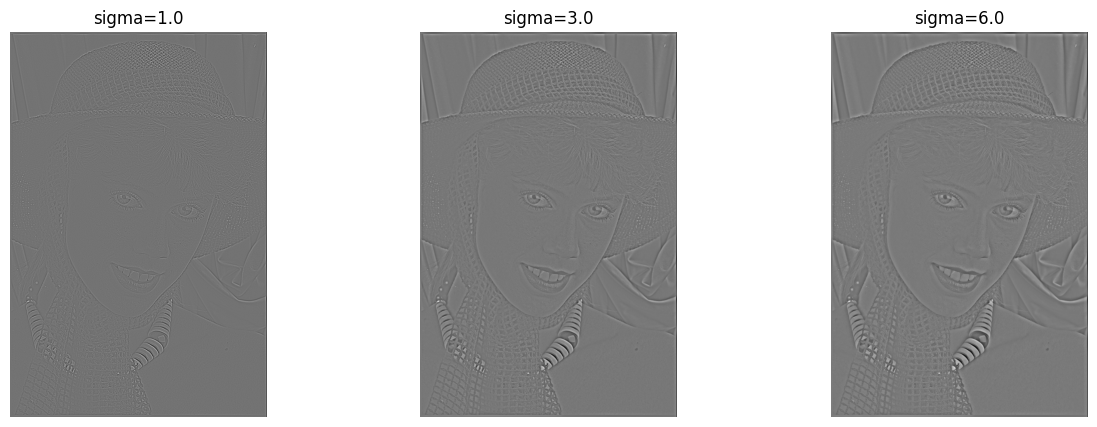

In [ ]:
sigmas = [1.0, 3.0, 6.0]

plt.figure(figsize=(15,5))

for i, s in enumerate(sigmas):
    hp = high_pass_filter(gray, ksize=15, sigma=s)
    plt.subplot(1,3,i+1)
    plt.imshow(normalize(hp), cmap="gray")
    plt.title(f"sigma={s}")
    plt.axis("off")

plt.show()


## Average Pooling и Max Pooling

> **Pooling** — это операция уменьшения пространственного размера изображения или карты признаков, при которой каждая локальная область заменяется одним агрегированным значением.
#### Идея Pooling

Мы берём окно размера $k \times k$ и заменяем его одним числом.

В отличие от свёртки, здесь нет обучаемых весов — мы просто применяем агрегирующую функцию.

Пусть $I$ — входное изображение, а $O$ — результат pooling.


#### Max Pooling

В каждом окне выбираем максимальное значение:

$$
O[y,x] = \max_{(i,j) \in \text{окно}} I[i,j].
$$

Эффект:

- сохраняет самые сильные активации,
- подчёркивает яркие признаки,
- делает модель менее чувствительной к небольшим смещениям.


#### Average Pooling

В каждом окне считаем среднее значение:

$$
O[y,x] = \frac{1}{k^2} \sum_{(i,j) \in \text{окно}} I[i,j].
$$

Эффект:

- сглаживает карту признаков,
- уменьшает шум,
- может ослаблять сильные активации.



#### Что происходит с размером изображения

Если окно $k \times k$ не перекрывается, размер изображения уменьшается примерно в $k$ раз по каждой оси.

Таким образом, pooling позволяет уменьшать размер карты признаков без введения новых параметров.


### Задание 2. Реализация MaxPooling

Твоя задача — реализовать MaxPooling.


#### Твой код

In [ ]:
def max_pooling(image, size):
  # Напиши код здесь
    pass


#### Решение для семинариста

In [ ]:
def max_pooling(image: np.ndarray, size: int = 2) -> np.ndarray:

    H, W = image.shape

    out_h = H // size
    out_w = W // size

    output = np.zeros((out_h, out_w), dtype=np.float32)

    for y in range(out_h):
        for x in range(out_w):
            patch = image[
                y*size : (y+1)*size,
                x*size : (x+1)*size
            ]
            output[y, x] = np.max(patch)

    return output


#### Применим pooling

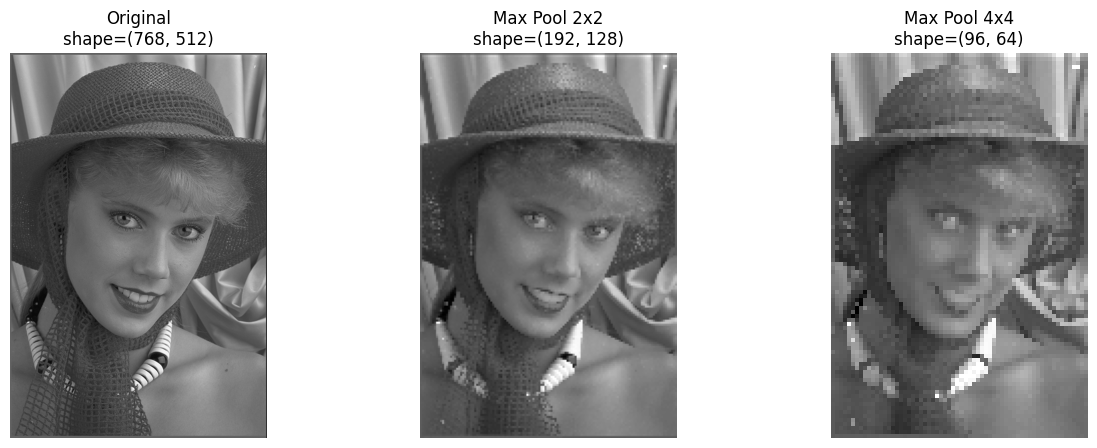

In [ ]:
pooled_4 = max_pooling(gray, size=4)
pooled_8 = max_pooling(gray, size=8)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(normalize(gray), cmap="gray")
plt.title(f"Original\nshape={gray.shape}")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(normalize(pooled_4), cmap="gray")
plt.title(f"Max Pool 2x2\nshape={pooled_4.shape}")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(normalize(pooled_8), cmap="gray")
plt.title(f"Max Pool 4x4\nshape={pooled_8.shape}")
plt.axis("off")

plt.show()


## Padding и Stride

При применении свёртки или pooling важно понимать, как меняется размер выходного изображения.

Для этого используются два параметра:

- Stride — шаг сдвига окна;
- Padding — добавление рамки вокруг изображения.



#### Stride

> Stride — это количество пикселей, на которое мы сдвигаем окно.

Если `stride = 1`:
- окно сдвигается на 1 пиксель;
- выход почти такого же размера.

Если `stride > 1`:
- мы пропускаем позиции;
- выход становится меньше.

Чем больше stride, тем сильнее уменьшается размер изображения.



#### Padding

При свёртке ядро не может корректно применяться к краям, потому что часть окна выходит за пределы изображения.

Padding решает эту проблему — он добавляет рамку вокруг изображения.

Чаще всего используется нулевой padding:

$$
I_{padded} = \text{pad}(I).
$$



#### Как padding влияет на размер

Пусть:

- размер входа — $H \times W$;
- размер ядра — $k \times k$;
- padding равен $p$;
- stride равен $s$.

Тогда размер выхода:

$$
H_{out} = \left\lfloor \frac{H + 2p - k}{s} \right\rfloor + 1;
$$

$$
W_{out} = \left\lfloor \frac{W + 2p - k}{s} \right\rfloor + 1.
$$



#### Типичные режимы

- Valid — без padding ($p=0$). Размер уменьшается.

- Same — padding подбирается так, чтобы размер выхода совпадал со входом (при `stride=1`).



#### Эффекты

Padding:
- позволяет контролировать размер выхода,
- сохраняет информацию у границ изображения.

Stride:
- уменьшает размер карты признаков,
- ускоряет вычисления,
- может приводить к потере деталей.


### Задание 3. Conv2D с padding и stride

Мы уже реализовали свёртку в режиме valid (без padding и со `stride = 1`). Теперь расширим реализацию.

Тебе нужно реализовать функцию: `conv2d(image, kernel, padding=0, stride=1)`.

Функция должна:

- добавлять нулевой padding вокруг изображения;
- учитывать шаг stride;
- корректно вычислять размер выходного изображения.



#### Твой код

In [ ]:
def conv2d(image, kernel, padding, stride):

    H, W = image.shape
    kH, kW = kernel.shape

    # Добавить padding
    # Напиши код здесь
    padded = None

    # Вычислить размеры выхода
    # Напиши код здесь
    out_h = None
    out_w = None

    # Создать выходной массив
    # Напиши код здесь
    output = None

    # Реализовать двойной цикл
    # Окно должно сдвигаться на stride
    # И использовать padded-изображение
    # Напиши код здесь

    return output


#### Решение для семинариста

In [ ]:
def conv2d(image, kernel, padding, stride):

    H, W = image.shape
    kH, kW = kernel.shape

    # 1) padding
    padded = np.pad(image,
                    ((padding, padding),
                     (padding, padding)),
                    mode='constant')

    # 2) размер выхода
    out_h = (H + 2*padding - kH) // stride + 1
    out_w = (W + 2*padding - kW) // stride + 1

    output = np.zeros((out_h, out_w), dtype=np.float32)

    # 3) свёртка
    for y in range(out_h):
        for x in range(out_w):
            patch = padded[
                y*stride : y*stride + kH,
                x*stride : x*stride + kW
            ]
            output[y, x] = np.sum(patch * kernel)

    return output


In [ ]:
# Простой массив 4x4
image = np.array([
    [ 1,  2,  3,  4],
    [ 5,  6,  7,  8],
    [ 9, 10, 11, 12],
    [13, 14, 15, 16]
], dtype=np.float32)

# Простое ядро 2x2
kernel = np.array([
    [1, 0],
    [0, 1]
], dtype=np.float32)

print("Input:")
print(image)
print("\nKernel:")
print(kernel)


Input:
[[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]
 [13. 14. 15. 16.]]

Kernel:
[[1. 0.]
 [0. 1.]]


#### Пример

In [ ]:
out_valid = conv2d(image, kernel, padding=0, stride=1)

print("Valid (padding=0, stride=1)")
print("Shape:", out_valid.shape)
print(out_valid)


Valid (padding=0, stride=1)
Shape: (3, 3)
[[ 7.  9. 11.]
 [15. 17. 19.]
 [23. 25. 27.]]


In [ ]:
out_same = conv2d(image, kernel, padding=1, stride=1)

print("With padding=1, stride=1")
print("Shape:", out_same.shape)
print(out_same)


With padding=1, stride=1
Shape: (5, 5)
[[ 1.  2.  3.  4.  0.]
 [ 5.  7.  9. 11.  4.]
 [ 9. 15. 17. 19.  8.]
 [13. 23. 25. 27. 12.]
 [ 0. 13. 14. 15. 16.]]


In [ ]:
out_stride2 = conv2d(image, kernel, padding=0, stride=2)

print("padding=0, stride=2")
print("Shape:", out_stride2.shape)
print(out_stride2)


padding=0, stride=2
Shape: (2, 2)
[[ 7. 11.]
 [23. 27.]]


### Вопросы для студентов
1) Почему padding увеличивает размер выхода?

2) Почему увеличение stride уменьшает размер быстрее?

3) Можно ли одновременно увеличить padding и stride?
   Как тогда изменится размер?


#### Ответы для семинариста

1) Padding увеличивает размер выхода по сравнению с режимом без padding, потому что мы искусственно расширяем вход рамкой. После этого ядро может встать в большее число позиций, в том числе около границ. В формуле это видно по члену $+ 2p$: чем больше $p$, тем больше возможный размер выхода.

2) При увеличении stride окно двигается более крупными шагами и проверяет меньше позиций. То есть мы как будто реже “сэмплируем” изображение свёрткой. Поэтому размер выхода уменьшается быстрее: в формуле stride стоит в знаменателе.

3) Да, padding и stride можно увеличивать одновременно. Padding работает в сторону увеличения размера, а stride — в сторону уменьшения, а итог определяется их балансом:
   $$
   H_{out} = \left\lfloor \frac{H + 2p - k}{s} \right\rfloor + 1
   $$
   $$
   W_{out} = \left\lfloor \frac{W + 2p - k}{s} \right\rfloor + 1
   $$
   То есть padding даёт ядру больше допустимых позиций, а stride одновременно делает шаг между ними более редким.